# Task 2: Predict Future Stock Prices (Short-Term)
Objective:
Use historical stock data to predict the next day&#39;s closing price.

In [1]:
import yfinance as yf
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


## Download stock data
Choose your stock Apple = "AAPL

In [21]:
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-12-31")

# Fix: Flatten the MultiIndex columns
df.columns = [col[0] for col in df.columns]

[*********************100%***********************]  1 of 1 completed


In [22]:
print("First 5 rows of the dataset: ")
print(df.head())

First 5 rows of the dataset: 
                Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928040  72.533080  71.708680  72.277563  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


In [23]:
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())


Dataset shape: (1257, 5)

Column names: ['Close', 'High', 'Low', 'Open', 'Volume']


In [24]:
print("Dataset info:")
print(df.info())

Dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1257 entries, 2020-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1257 non-null   float64
 1   High    1257 non-null   float64
 2   Low     1257 non-null   float64
 3   Open    1257 non-null   float64
 4   Volume  1257 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB
None


In [25]:
print("SUMMARY STATISTICS")
print(df.describe())

SUMMARY STATISTICS
             Close         High          Low         Open        Volume
count  1257.000000  1257.000000  1257.000000  1257.000000  1.257000e+03
mean    151.439654   152.961785   149.740608   151.283475  9.061168e+07
std      41.816681    41.955070    41.591867    41.756220  5.324605e+07
min      54.213596    55.211512    51.372077    55.110030  2.323470e+07
25%     126.366203   127.451658   124.349256   125.840223  5.546960e+07
50%     150.080353   151.830380   148.084685   149.906081  7.629970e+07
75%     175.908401   177.608481   174.476804   175.755177  1.077601e+08
max     257.612732   258.686881   256.230300   256.787255  4.265100e+08


In [26]:
#  check missing values 
print("Missing values in each column: ")
print(df.isnull().sum())

Missing values in each column: 
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [28]:
# Create features (X) and target (y)
# We want to predict NEXT DAY's closing price
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

In [29]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows of features (today's data):")
print(X.head())
print("\nFirst 5 rows of target (tomorrow's close):")
print(y.head())


Features shape: (1255, 4)
Target shape: (1255,)

First 5 rows of features (today's data):
                 Open       High        Low     Volume
Date                                                  
2020-01-02  71.409778  72.460776  71.156674  135480400
2020-01-03  71.629138  72.455950  71.472454  146322800
2020-01-06  70.819201  72.306499  70.568503  118387200
2020-01-07  72.277563  72.533080  71.708680  108872000
2020-01-08  71.631552  73.386423  71.631552  132079200

First 5 rows of target (tomorrow's close):
Date
2020-01-02    71.696632
2020-01-03    72.267929
2020-01-06    71.928040
2020-01-07    73.085106
2020-01-08    74.637489
Name: Next_Close, dtype: float64


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [32]:
len(X_train),len(X_test)

(1004, 251)

In [33]:
X_train.shape,X_test.shape

((1004, 4), (251, 4))

In [34]:
y_train.shape

(1004,)

## Train models

In [35]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [38]:
lr_model.score(X_train,y_train)*100,lr_model.score(X_test,y_test)*100

(99.37278464603271, 98.4918485926046)

In [42]:
print("MODEL PERFORMANCE")
print(f"Linear Regression R² Score: {r2_score(y_test, lr_pred):.4f}")
print(f"linear Regression MSE: {mean_squared_error(y_test,lr_pred):.4f}")

MODEL PERFORMANCE
Linear Regression R² Score: 0.9849
linear Regression MSE: 9.6403


In [44]:
y_test.head(3)

Date
2023-12-28    190.550476
2023-12-29    183.731293
2024-01-02    182.355621
Name: Next_Close, dtype: float64

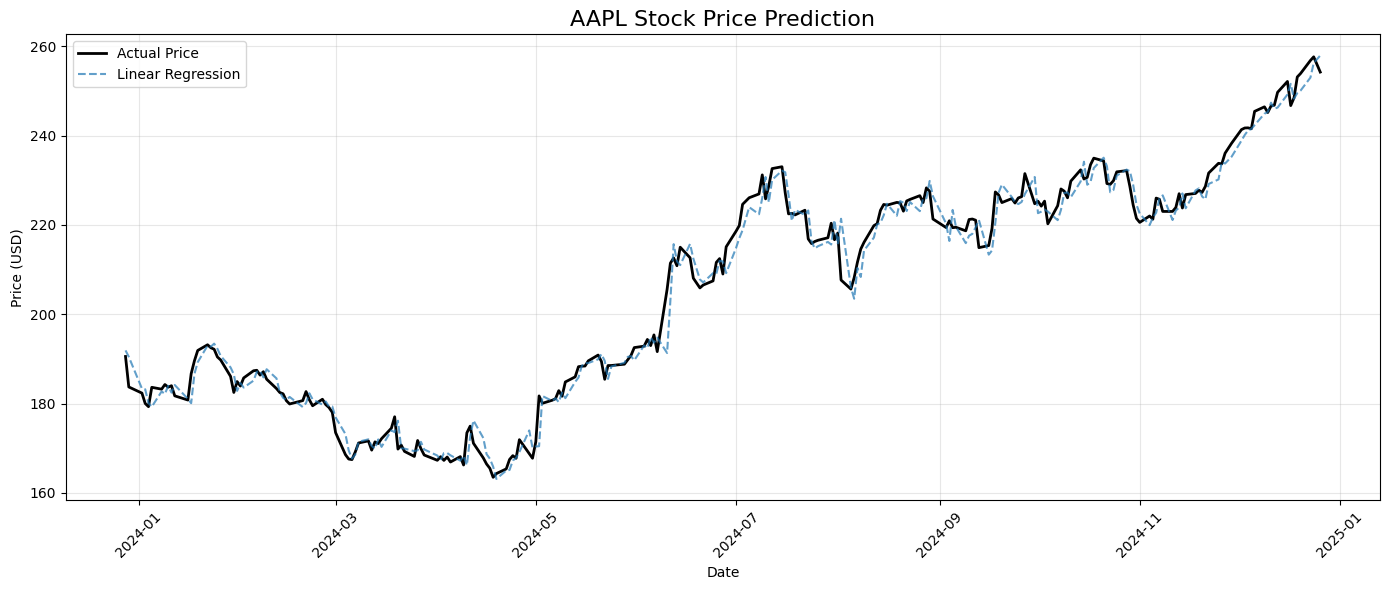

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Price', linewidth=2, color='black')
plt.plot(y_test.index, lr_pred, label='Linear Regression', linestyle='--', alpha=0.7)

plt.title(f'{ticker} Stock Price Prediction', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [53]:
# Get user input
open_price = float(input("Enter today's Open price: $"))
high_price = float(input("Enter today's High price: $"))
low_price = float(input("Enter today's Low price: $"))
volume = float(input("Enter today's Volume: "))

# Create array for prediction
today_values = np.array([[open_price, high_price, low_price, volume]])

# Predict
tomorrow_price = lr_model.predict(today_values)[0]

# Show result
print(f"📈 Based on today's values:")
print(f"   Open: ${open_price:.2f}")
print(f"   High: ${high_price:.2f}") 
print(f"   Low: ${low_price:.2f}")
print(f"   Volume: {volume:,.0f}")
print()
print(f"🔮 PREDICTED TOMORROW'S CLOSE: ${tomorrow_price:.2f}")



📈 Based on today's values:
   Open: $175.50
   High: $178.20
   Low: $174.80
   Volume: 85,000,000

🔮 PREDICTED TOMORROW'S CLOSE: $177.32


c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [49]:
rf_model.score(X_train,y_train)*100,rf_model.score(X_test,y_test)*100

(99.88731813478603, -1.1317283951658874)